In [1]:
import re
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
os.chdir('../downloads')
FILE_PATH = 'SMP01I-1d5p-1600x1600x1700-16b.raw'

In [3]:
def get_dimensions(filename):
    """Returns the dimensions of the raw picture from the filename"""
    return [int(x) for x in re.sub(f'(.+)-(\d+x\d+x\d+)(.+)','\\2',filename).split('x')]

def read_raw(filepath):
    """Reads and returns the image 3D array"""
    with open(filepath, 'rb') as f:
      img_str = f.read()
    arr = np.frombuffer(img_str, np.uint16)
    h,w,d = get_dimensions(filepath)
    return np.reshape(arr,(d,h,w))

def plot_image(image):
    """Plots an image"""
    plt.imshow(image, cmap=plt.cm.gray_r)
    plt.axis('off')
    return plt.show()
    

def plot_slice(im_array, i):
    """Plots a slice of a 3d image given its z index"""
    im_ = im_array[i,:,:]
    return plot_image(im_)

In [4]:
#read data
img_arr = read_raw(FILE_PATH)

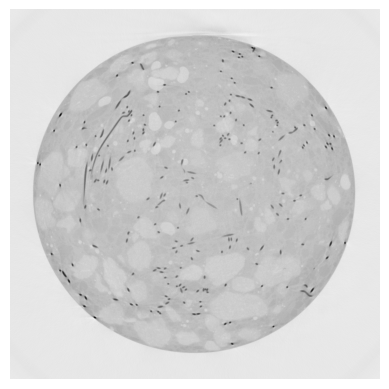

In [11]:
#plot any image
plot_slice(img_arr,15)

(960, 960)


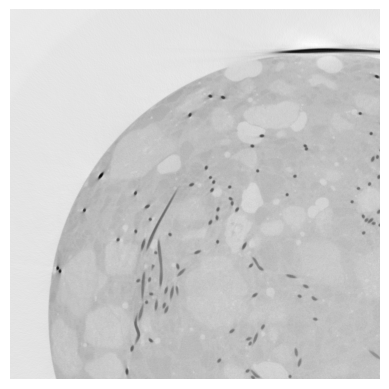

(960, 960)


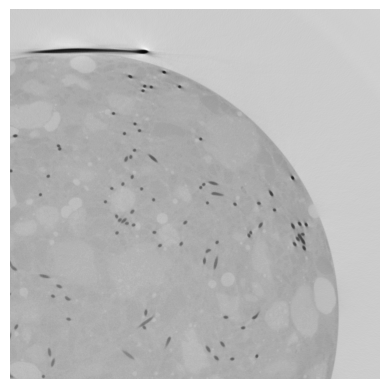

(960, 960)


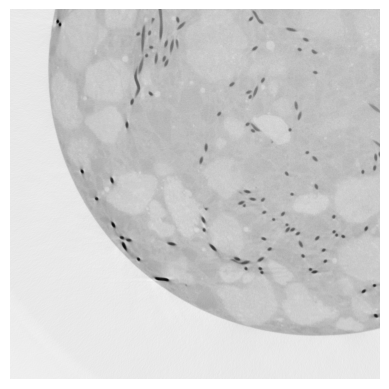

(960, 960)


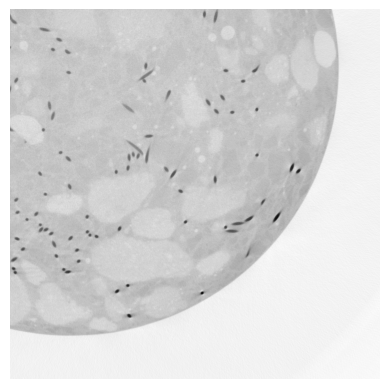

In [12]:
def quadrants(image, overlap=0.1):
    """Splits image into 4 parts using an overlap"""
    h,w = image.shape
    midy,midx = h//2,w//2
    oly = int(h*overlap)
    olx = int(w*overlap)
    return image[0:midy+oly,0:midx+olx],image[0:midy+oly,midx-olx:],image[midy-oly:,0:midx+olx],image[midy-oly:,midx-olx:]

for im1 in quadrants(img_arr[1,:,:],.1):
    print(im1.shape)
    plot_image(im1)
    

In [13]:
def cut_and_save(filepath, output_size = (512,512)):
    """Gets a raw 3D image file path and saves to new dir"""
    im_ar = read_raw(filepath)
    
    dir_name = filepath.replace('.raw','')
    os.makedirs(dir_name,exist_ok=True)
    
    #loop through 3d scan
    for i in range(im_ar.shape[0]):
        slice_ = im_ar[i,:,:]
        qd_dict = dict(zip(['UL','UR','BL','BR'],quadrants(slice_)))
        
        for nm,im in qd_dict.items():
            im_ = 1-(im/(2**16-1)).astype(float)
            im_ = cv2.resize(im_,output_size)
            fname = f"{dir_name}/{str(i).rjust(4,'0')}_{nm}.jpg"
            cv2.imwrite(fname,im_*255)
     

In [ ]:
cut_and_save(FILE_PATH)